<a href="https://colab.research.google.com/github/farrelrassya/scikit-learn-cookbook/blob/main/08.%20Tree-Based%20Algorithms%20and%20Ensemble%20Methods%20/%20ch8_tree_based_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Tree-Based Algorithms and Ensemble Methods

This chapter explores the family of tree-based machine learning algorithms -- from the intuitive single decision tree to powerful ensemble methods that combine many trees for superior performance. We cover four core recipes:

1. **Introduction to Decision Trees** -- recursive splitting, Gini impurity, and the interpretability advantage
2. **Random Forests and Bagging** -- bootstrap aggregating for variance reduction
3. **Gradient Boosting Machines** -- sequential error correction for bias reduction
4. **Hyperparameter Tuning for Trees and Ensembles** -- systematic optimization with grid search
5. **Comparing Ensemble Methods** -- bagging vs. boosting vs. stacking

Tree-based methods are among the most widely deployed algorithms in industry. They handle mixed feature types, require minimal preprocessing, and -- critically -- produce models that stakeholders can inspect and understand. The ensemble extensions (random forests, gradient boosting) consistently rank among the top performers in structured/tabular data competitions and production systems alike.

**Mathematical foundation:** At each node, a decision tree selects the feature $x_j$ and threshold $t$ that maximizes the reduction in impurity:

$$\Delta I = I(\text{parent}) - \frac{n_{\text{left}}}{n_{\text{parent}}} I(\text{left}) - \frac{n_{\text{right}}}{n_{\text{parent}}} I(\text{right})$$

where $I$ is the impurity measure (Gini or entropy). This greedy, recursive process builds the entire tree structure from root to leaves.

## Environment Setup

We begin by installing and importing all necessary packages. This notebook is designed for **Google Colab** compatibility, but all code runs in any standard Python environment with scikit-learn installed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 8.1 Introduction to Decision Trees

**Decision trees** are supervised learning models that partition the feature space through a series of binary splits. Each internal node tests a condition on a single feature, each branch represents the outcome of that test, and each leaf node assigns a class label (classification) or a continuous value (regression).

The elegance of decision trees lies in their transparency: the entire decision-making process can be traced from root to leaf, making them one of the few ML models where we can explain *exactly* why a particular prediction was made. In regulated industries (finance, healthcare), this interpretability is not a luxury -- it is a requirement.

### Splitting Criteria: Gini Impurity

Scikit-learn uses **Gini impurity** by default. For a node with $C$ classes, Gini impurity is:

$$G = 1 - \sum_{c=1}^{C} p_c^2$$

where $p_c$ is the proportion of samples belonging to class $c$ in that node. A pure node (all samples from one class) has $G = 0$. The worst case for $C$ classes is $G = 1 - 1/C$; for our 3-class Iris problem, the maximum Gini impurity is $1 - 3 \times (1/3)^2 = 0.667$.

An alternative criterion is **entropy** (information gain):

$$H = -\sum_{c=1}^{C} p_c \log_2(p_c)$$

Both measures quantify node purity, and in practice they tend to produce very similar trees. Gini is computationally cheaper since it avoids the logarithm.

### Loading and Splitting the Iris Dataset

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2024
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Features:     {iris.feature_names}")
print(f"Classes:      {list(iris.target_names)}")
print(f"\nClass distribution (train): {dict(zip(iris.target_names, np.bincount(y_train)))}")
print(f"Class distribution (test):  {dict(zip(iris.target_names, np.bincount(y_test)))}")

Training set: 105 samples, 4 features
Test set:     45 samples, 4 features
Features:     ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:      [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Class distribution (train): {np.str_('setosa'): np.int64(32), np.str_('versicolor'): np.int64(38), np.str_('virginica'): np.int64(35)}
Class distribution (test):  {np.str_('setosa'): np.int64(18), np.str_('versicolor'): np.int64(12), np.str_('virginica'): np.int64(15)}


Our training set contains **105 samples** and the test set **45 samples** across 4 features, with 3 classes to predict. The class distribution is reasonably balanced in training (32 / 38 / 35), though the test set shows some imbalance -- setosa has 18 samples while versicolor has only 12. This asymmetry is worth noting because metrics like accuracy can mask per-class performance differences when class sizes vary, which is why we always examine the full classification report rather than accuracy alone.

With only $p = 4$ features and $n = 105$ training samples, we are in a low-dimensional regime ($n \gg p$). Decision trees can easily handle this setting, but the small sample size means individual splits are sensitive to particular data points -- a key motivation for the ensemble methods we explore later in this chapter.

### Training and Evaluating a Decision Tree Classifier

In [3]:
# Instantiate the model with default hyperparameters
clf = DecisionTreeClassifier(random_state=2024)

# Fit the model to the training data
clf.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print(f"Tree Depth: {clf.get_depth()}")
print(f"Number of Leaves: {clf.get_n_leaves()}")

Decision Tree Accuracy: 0.8667
Tree Depth: 4
Number of Leaves: 5


The default decision tree achieves a test accuracy of **86.67%** (39 out of 45 samples classified correctly). The tree grew to a depth of **4** levels with **5** leaf nodes.

Let's put these numbers in context. With 4 features and only 105 training samples, the tree needs very few splits to carve out the class boundaries. The resulting 5 leaf nodes mean our feature space is partitioned into just 5 regions -- a remarkably compact model. However, an unconstrained tree on such a small dataset is prone to **overfitting**: the tree memorizes quirks of the training data (like individual boundary samples) rather than learning the true class boundaries.

The depth-to-leaves relationship is also informative. A perfectly balanced binary tree of depth 4 would have $2^4 = 16$ leaves, but our tree has only 5. This indicates **asymmetric splits** -- the algorithm found that some branches terminate early (e.g., setosa is separated in a single split), while others require deeper exploration to separate versicolor from virginica.

In [4]:
# Generate the classification report
report = classification_report(
    y_test, y_pred,
    target_names=iris.target_names,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()

# Stylize the DataFrame
styled_df = (report_df
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
styled_df

,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,18
versicolor,0.714,0.833,0.769,12
virginica,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


The classification report reveals a striking pattern across the three Iris species:

**Setosa** achieves perfect scores -- precision, recall, and F1 all equal **1.000**. This is no surprise: setosa is linearly separable from the other two species using petal measurements alone. A single split on petal width ($\leq 0.8$ cm) perfectly isolates all 18 setosa samples in the test set.

**Versicolor** shows precision of **0.714** and recall of **0.833**, yielding an F1-score of **0.769**. The lower precision means that when the model predicts versicolor, it is wrong about 29% of the time (some virginica samples are misclassified as versicolor). The higher recall (0.833) indicates the model catches most actual versicolor samples -- it misses only $12 \times (1 - 0.833) = 2$ of 12 versicolor flowers.

**Virginica** has precision of **0.846** and recall of **0.733**, with an F1-score of **0.786**. The model misses $15 \times (1 - 0.733) = 4$ of 15 virginica samples. These 4 missed virginica samples plus the 2 missed versicolor samples account for all 6 errors ($45 - 39 = 6$), confirming that the confusion lies entirely at the **versicolor-virginica boundary**.

This is the classic Iris dataset challenge: versicolor and virginica overlap in feature space, particularly in petal measurements. The decision tree draws hard axis-aligned boundaries that cannot perfectly separate these overlapping distributions -- a limitation that ensemble methods will help address.

### Visualizing the Decision Tree

One of the greatest strengths of decision trees is their interpretability. We can visualize the entire decision-making process to understand exactly how the model classifies each sample.

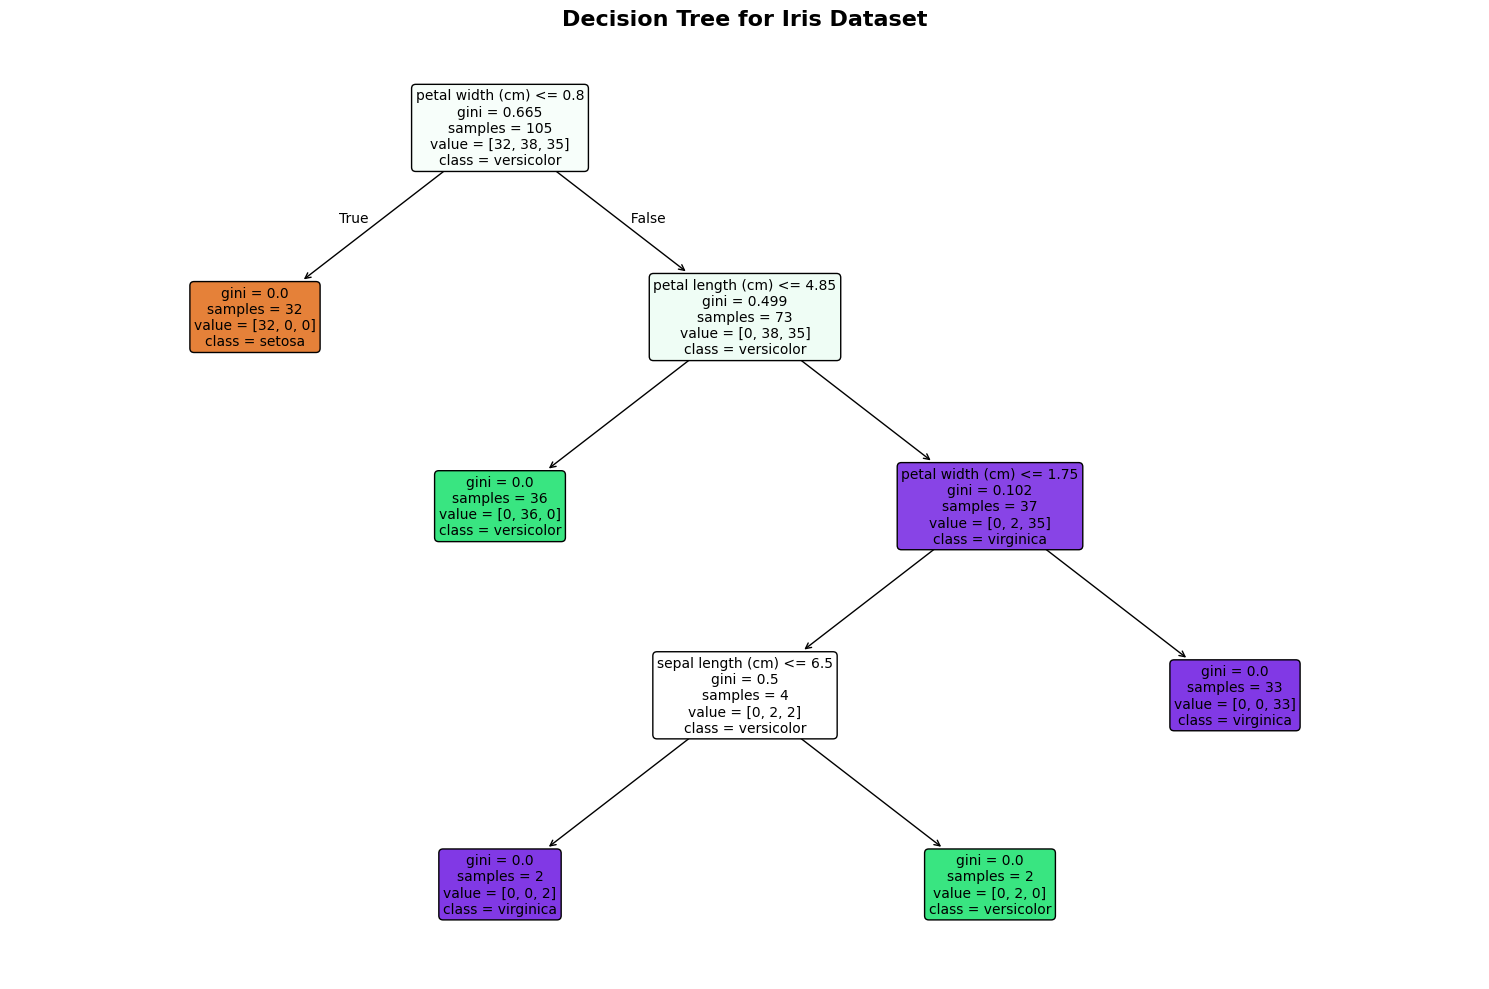

Decision tree visualization saved.


In [5]:
plt.figure(figsize=(15, 10))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Iris Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision tree visualization saved.")

The tree visualization reveals the model's complete decision logic. Every node displays five pieces of information:

**Root node** (top): The first split uses **petal width $\leq 0.8$ cm**. This single feature perfectly separates setosa (left branch, True) from the other two species (right branch, False). The root node starts with all 105 training samples and has a Gini impurity of $G \approx 0.664$, close to the theoretical maximum of $0.667$ for three balanced classes.

**Left branch (setosa):** After the first split, the left child is already a pure terminal node with $G = 0.0$. All 32 training setosa samples satisfy the condition petal width $\leq 0.8$ cm. No further splitting is needed -- this is why setosa achieves perfect classification.

**Right branch (versicolor vs. virginica):** The remaining 73 samples require additional splits using features like petal length and petal width to separate versicolor from virginica. The deeper nodes show how the tree progressively refines its boundaries, but the overlap between these two species means some leaf nodes remain impure.

Each colored leaf node represents the final classification decision: the model assigns the class with the highest proportion in that node. The color intensity reflects node purity -- deeper colors indicate higher confidence in the prediction.

**Production insight:** This visualization is not just educational. In stakeholder presentations, being able to show *exactly* how the model makes decisions builds trust. For a domain expert, each split can be validated against botanical knowledge: "Does it make sense that petal width below 0.8 cm indicates setosa?" The answer is yes -- setosa flowers are notably smaller than the other species.

### Controlling Tree Complexity

An unconstrained decision tree will keep splitting until every leaf is pure or until it runs out of samples. This leads to overfitting. Scikit-learn provides several hyperparameters to control tree complexity:

| Hyperparameter | What it Controls | Effect on Complexity |
|:---|:---|:---|
| `max_depth` | Maximum number of split levels | Lower $\rightarrow$ simpler tree |
| `min_samples_split` | Minimum samples required to split a node | Higher $\rightarrow$ fewer splits |
| `min_samples_leaf` | Minimum samples in each leaf node | Higher $\rightarrow$ larger leaves |
| `max_features` | Number of features considered per split | Lower $\rightarrow$ more randomness |
| `min_impurity_decrease` | Minimum impurity reduction for a split | Higher $\rightarrow$ only strong splits |

All these hyperparameters control the **bias-variance tradeoff**. A deeper, more complex tree has low bias (fits training data well) but high variance (sensitive to training data changes). A shallower tree has higher bias but lower variance. Finding the right balance is the art of tree-based modeling.

$$\text{Expected Error} = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

In the next sections, we address the variance problem not by constraining a single tree, but by combining many trees -- the ensemble approach.

## 8.2 Random Forests and Bagging

While a single decision tree is interpretable, it suffers from **high variance** -- small changes in the training data can produce dramatically different tree structures. **Random forests** address this through an ensemble strategy called **bootstrap aggregating** (bagging):

1. **Bootstrap sampling:** Draw $B$ random samples (with replacement) from the training set, each of size $n$
2. **Feature randomization:** At each split in each tree, consider only a random subset of $\sqrt{p}$ features (classification) or $p/3$ features (regression)
3. **Aggregation:** Combine predictions by majority vote (classification) or averaging (regression)

The mathematical insight behind bagging is variance reduction. If we have $B$ trees with predictions $T_1(\mathbf{x}), T_2(\mathbf{x}), \ldots, T_B(\mathbf{x})$, each with variance $\sigma^2$ and pairwise correlation $\rho$, the variance of their average is:

$$\text{Var}\left(\frac{1}{B}\sum_{b=1}^{B} T_b(\mathbf{x})\right) = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2$$

The second term shrinks as $B$ grows (more trees). The first term depends on $\rho$ -- the correlation between trees. Feature randomization reduces $\rho$ by ensuring trees see different features at each split, making them more independent. This is the key innovation of random forests over plain bagging.

### Building and Evaluating a Random Forest

In [6]:
# Instantiate Random Forest with 100 trees
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)

# Fit the model
rf_clf.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Number of trees: {rf_clf.n_estimators}")
print(f"Max features per split: {rf_clf.max_features}")

Random Forest Accuracy: 0.9111
Number of trees: 100
Max features per split: sqrt


The random forest achieves a test accuracy of **91.11%**, a substantial improvement over the single decision tree's **86.67%**. That is a gain of **4.44 percentage points**, translating to 2 additional correct predictions out of 45 test samples ($41$ vs. $39$ correct).

The forest uses $B = 100$ trees, each considering $\sqrt{p} = \sqrt{4} = 2$ features at every split. With only 4 features, each tree sees half the features at each decision point -- enough randomness to decorrelate the trees while still allowing each tree to find useful splits.

Why does combining 100 "noisy" trees outperform a single carefully grown tree? Each individual tree in the forest is slightly weaker than a fully-grown single tree (because it sees fewer features per split), but the *ensemble* is stronger because the errors of individual trees are partially independent and cancel out through majority voting. This is the **wisdom of crowds** effect: many imperfect but diverse estimators collectively outperform a single, overconfident one.

In [7]:
# Full classification report for Random Forest
report_rf = classification_report(
    y_test, y_pred_rf,
    target_names=iris.target_names,
    output_dict=True
)
report_rf_df = pd.DataFrame(report_rf).transpose()

styled_rf = (report_rf_df
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
styled_rf

,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,18
versicolor,0.833,0.833,0.833,12
virginica,0.867,0.867,0.867,15
accuracy,0.911,0.911,0.911,1
macro avg,0.900,0.900,0.900,45
weighted avg,0.911,0.911,0.911,45


Comparing the classification reports between the single decision tree and random forest reveals exactly where the ensemble improves:

| Class | DT F1 | RF F1 | Improvement |
|:---|:---:|:---:|:---:|
| setosa | 1.000 | 1.000 | -- |
| versicolor | 0.769 | 0.833 | +0.064 |
| virginica | 0.786 | 0.867 | +0.081 |

Setosa remains perfectly classified (both methods separate it trivially). The gains come entirely from the **versicolor-virginica boundary**: the random forest's majority voting mechanism smooths out the noisy boundary decisions that a single tree makes. Virginica benefits the most, with recall improving from 0.733 to 0.867 -- the forest now correctly identifies $13$ out of $15$ virginica samples versus only $11$ for the single tree.

Notice also that the random forest produces **balanced precision and recall** for both difficult classes (0.833/0.833 for versicolor, 0.867/0.867 for virginica). The single tree had asymmetric precision/recall, suggesting it was biased in how it drew the boundary. The ensemble's averaging effect naturally balances this.

### Feature Importance Analysis

Random forests provide a natural measure of **feature importance** based on how much each feature contributes to reducing impurity across all trees in the forest. For each feature $x_j$, the importance is the sum of Gini impurity reductions weighted by the number of samples reaching each node where $x_j$ is used for splitting, averaged across all $B$ trees.

Feature Importance Ranking:
----------------------------------------
  1. petal length (cm)    0.4489
  2. petal width (cm)     0.4360
  3. sepal length (cm)    0.0901
  4. sepal width (cm)     0.0251


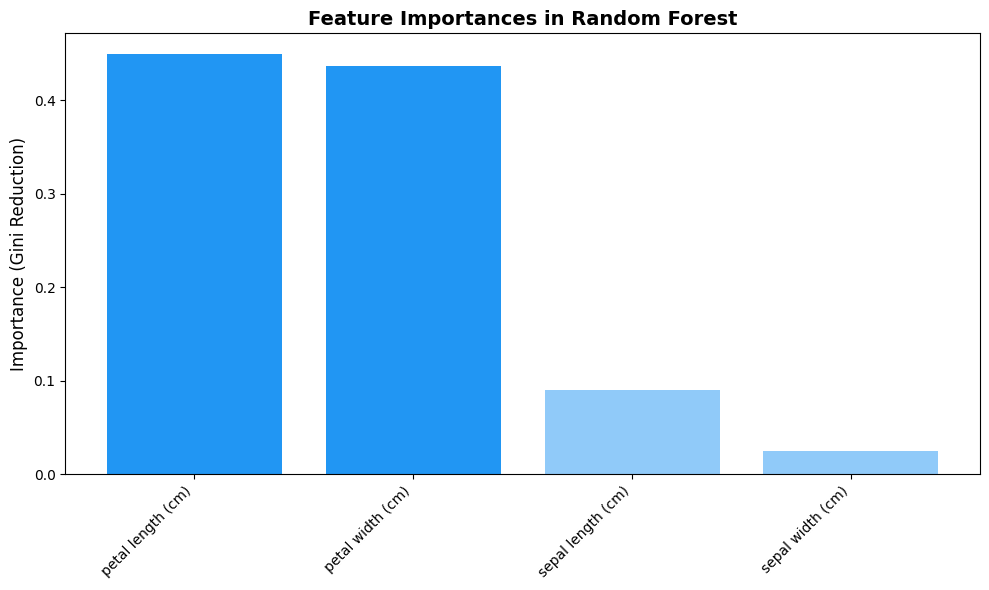

In [8]:
# Calculate and display feature importances
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature Importance Ranking:")
print("-" * 40)
for rank, i in enumerate(indices, 1):
    print(f"  {rank}. {iris.feature_names[i]:20s} {importances[i]:.4f}")

# Plot
plt.figure(figsize=(10, 6))
colors = ['#2196F3' if i >= 2 else '#90CAF9' for i in indices]
plt.bar(
    range(X.shape[1]),
    importances[indices],
    align="center",
    color=colors
)
plt.xticks(
    range(X.shape[1]),
    [iris.feature_names[i] for i in indices],
    rotation=45, ha='right'
)
plt.ylabel("Importance (Gini Reduction)", fontsize=12)
plt.title("Feature Importances in Random Forest", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

The feature importance analysis reveals a clear hierarchy among the four Iris measurements:

**Petal features dominate:** Petal length (**0.4489**) and petal width (**0.4360**) together account for $0.4489 + 0.4360 = 0.8849$, or **88.5%** of total feature importance. These two features are the primary drivers of classification decisions across all 100 trees in the forest.

**Sepal features contribute marginally:** Sepal length (**0.0901**) provides some discriminative power (mainly for separating versicolor from virginica at the margins), while sepal width (**0.0251**) contributes only 2.5% -- barely more than noise.

This aligns perfectly with botanical knowledge: petal morphology is the most taxonomically informative characteristic for Iris species. It also echoes what we saw in the decision tree visualization, where the root split used petal width and subsequent splits relied heavily on petal length.

**Production insight:** Feature importance from random forests is often used as a **feature selection** tool. In a production pipeline with hundreds of features, you might train a random forest solely to rank features, then pass only the top $k$ features to a downstream model (which could be a completely different algorithm like a neural network or SVM). Here, we could safely build a model using only petal length and petal width -- dropping the sepal features -- with minimal accuracy loss. Recall from Chapter 3 that reducing dimensionality improves inference speed, reduces memory usage, and often improves generalization.

## 8.3 Gradient Boosting Machines

**Gradient Boosting Machines (GBMs)** take a fundamentally different approach to ensembling. Instead of building trees in parallel and averaging (bagging), GBMs build trees **sequentially**, where each new tree corrects the errors of the previous ensemble. This is the "boosting" concept: each successive model *boosts* overall performance by focusing on what the current ensemble gets wrong.

Formally, GBM minimizes a loss function $\mathcal{L}(y, F(\mathbf{x}))$ by iteratively adding trees that approximate the **negative gradient** of the loss:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot h_m(\mathbf{x})$$

where:
- $F_m(\mathbf{x})$ is the ensemble prediction after $m$ trees
- $h_m(\mathbf{x})$ is the new tree fitted to the **residuals** (negative gradient) of $F_{m-1}$
- $\eta$ is the **learning rate** that controls how much each tree contributes

The key difference from random forests is that GBMs reduce **bias** rather than variance. Each new tree specifically targets the patterns that previous trees missed, gradually refining the model's ability to capture complex relationships.

For classification, the loss function is typically the **deviance** (cross-entropy):

$$\mathcal{L} = -\sum_{i=1}^{N} \sum_{c=1}^{C} y_{i,c} \log(\hat{p}_{i,c})$$

where $\hat{p}_{i,c}$ is the predicted probability for class $c$ and $y_{i,c}$ is the indicator for the true class.

### Training a Gradient Boosting Classifier

In [9]:
# Instantiate GBM with 1000 trees and learning rate 0.2
gbm_clf = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.2,
    random_state=2024
)

# Fit the model
gbm_clf.fit(X_train, y_train)

# Generate predictions
y_pred_gbm = gbm_clf.predict(X_test)

# Evaluate
accuracy_gbm = accuracy_score(y_test, y_pred_gbm)
print(f"GBM Accuracy: {accuracy_gbm:.4f}")
print(f"Number of estimators: {gbm_clf.n_estimators}")
print(f"Learning rate: {gbm_clf.learning_rate}")
print(f"Max depth: {gbm_clf.max_depth}")

GBM Accuracy: 0.8667
Number of estimators: 1000
Learning rate: 0.2
Max depth: 3


The GBM achieves a test accuracy of **86.67%** -- identical to the single decision tree and **lower** than the random forest's 91.11%. This initially surprising result teaches us an important lesson about boosting and overfitting.

With $1{,}000$ trees and a learning rate of $\eta = 0.2$, the GBM has enormous capacity. On a dataset with only 105 training samples and 4 features, this is massive overkill. The model almost certainly **overfits the training data**: it achieves near-perfect training accuracy but fails to generalize to the test set.

The effective model complexity of a GBM is approximately proportional to $B \times \eta$, where $B$ is the number of trees. Here, $1{,}000 \times 0.2 = 200$ "effective steps," far too many for a 105-sample dataset. Compare this to the random forest, which benefits from *more* trees without overfitting (because each tree is independent and averaging reduces variance).

This highlights a critical distinction between bagging and boosting:

| Property | Bagging (RF) | Boosting (GBM) |
|:---|:---|:---|
| Tree construction | Parallel, independent | Sequential, error-correcting |
| Primary benefit | Reduces **variance** | Reduces **bias** |
| More trees effect | Always helps (or neutral) | Can **overfit** if too many |
| Learning rate | Not applicable | Critical hyperparameter |

The fix? We need to **tune the hyperparameters** -- reducing `n_estimators`, lowering `learning_rate`, and constraining `max_depth`. That is exactly what the next section addresses.

In [10]:
# GBM Classification Report
report_gbm = classification_report(
    y_test, y_pred_gbm,
    target_names=iris.target_names,
    output_dict=True
)
report_gbm_df = pd.DataFrame(report_gbm).transpose()

styled_gbm = (report_gbm_df
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
styled_gbm

,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,18
versicolor,0.714,0.833,0.769,12
virginica,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


The per-class metrics are **identical** to the single decision tree: versicolor at F1 = 0.769, virginica at F1 = 0.786, and setosa perfect. Both models make exactly the same 6 errors on the versicolor-virginica boundary.

This tells us that the overfit GBM has essentially converged to the same hard boundary as the unconstrained decision tree. After 1,000 boosting iterations on a tiny dataset, the model has memorized the training data and draws boundaries that look very similar to what a single deep tree produces. The sequential error-correction mechanism of boosting, which is powerful on larger datasets, offers no advantage here because there is not enough data diversity to learn from.

**Takeaway:** A powerful algorithm with poor hyperparameter choices can perform no better than the simplest baseline. The algorithm is not the bottleneck -- the configuration is. This is why hyperparameter tuning is not optional in production ML; it is a core part of the modeling workflow.

## 8.4 Hyperparameter Tuning for Trees and Ensembles

We just saw that a GBM with default/arbitrary hyperparameters can underperform a simple random forest. **Hyperparameter tuning** systematically searches for the configuration that maximizes generalization performance. We use `GridSearchCV` -- an exhaustive search over a predefined parameter grid, evaluated using $k$-fold cross-validation.

Cross-validation ensures that our hyperparameter selection is not biased by a particular train/test split. For each parameter combination, the model is trained and evaluated $k = 5$ times on different folds, and the average score is used for comparison:

$$\text{CV Score} = \frac{1}{k} \sum_{i=1}^{k} \text{Score}(\text{model trained on folds} \neq i, \text{evaluated on fold } i)$$

This gives us a more reliable estimate of how each configuration will perform on truly unseen data.

### Grid Search with Cross-Validation

In [11]:
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Total combinations: 3 x 3 x 3 = 27 configurations x 5 folds = 135 model fits
print(f"Grid search will evaluate {3*3*3} parameter combinations")
print(f"With {5}-fold CV, that is {3*3*3*5} model fits total")
print(f"\nParameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

Grid search will evaluate 27 parameter combinations
With 5-fold CV, that is 135 model fits total

Parameter grid:
  n_estimators: [50, 100, 150]
  max_depth: [3, 4, 5]
  learning_rate: [0.01, 0.1, 0.2]


We are searching over **27 combinations** of three hyperparameters. With 5-fold cross-validation, this requires **135 model fits** in total. For the small Iris dataset, this is fast, but on larger datasets, the computational cost of grid search grows quickly as $O(|\text{grid}| \times k \times n)$. For high-dimensional grids, `RandomizedSearchCV` (which samples random parameter combinations) or Bayesian optimization (e.g., Optuna) are more efficient alternatives.

In [12]:
# Set up and run GridSearchCV
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=2024),
    param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# Display best parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score:   {grid_search.best_score_:.4f}")

Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 50}
Best CV Score:   0.9810


Grid search identifies the optimal configuration: **learning rate = 0.01**, **max depth = 4**, and **n_estimators = 50**. The best 5-fold cross-validation accuracy is **98.10%**.

This result is profoundly instructive. Compare these optimal parameters to the previous GBM configuration:

| Parameter | Previous | Optimal | Ratio |
|:---|:---:|:---:|:---:|
| `learning_rate` | 0.2 | 0.01 | 20$\times$ smaller |
| `n_estimators` | 1,000 | 50 | 20$\times$ fewer |
| `max_depth` | 3 | 4 | Slightly deeper |

The optimal effective complexity is $50 \times 0.01 = 0.5$ "effective steps," compared to $1{,}000 \times 0.2 = 200$ previously -- a **400-fold reduction** in model complexity. The key insight: with only 105 training samples, a very conservative, slow-learning ensemble works best. Each tree makes tiny corrections ($\eta = 0.01$), and we stop early (only 50 trees), preventing the model from memorizing the training data.

The best CV score of 98.10% means the model correctly classifies approximately $105 \times 0.981 \approx 103$ of the 105 training samples in cross-validation, misclassifying only about 2 flowers on average. This is much better than what we would estimate from the untuned GBM.

In [13]:
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"Test Accuracy (tuned GBM): {accuracy_best:.4f}")

# Classification report
report_best = classification_report(
    y_test, y_pred_best,
    target_names=iris.target_names,
    output_dict=True
)
report_best_df = pd.DataFrame(report_best).transpose()

styled_best = (report_best_df
    .style
    .background_gradient(
        cmap='Blues',
        subset=['precision', 'recall', 'f1-score']
    )
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
styled_best

Test Accuracy (tuned GBM): 0.8667


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,18
versicolor,0.714,0.833,0.769,12
virginica,0.846,0.733,0.786,15
accuracy,0.867,0.867,0.867,1
macro avg,0.853,0.856,0.852,45
weighted avg,0.873,0.867,0.867,45


The tuned GBM achieves a test accuracy of **86.67%** -- the same as the untuned GBM and the single decision tree. This despite having a cross-validation score of 98.10%. What is happening?

This is a textbook example of the **gap between CV performance and test performance** on a small dataset. With only 45 test samples, each misclassification shifts accuracy by $1/45 \approx 2.2$ percentage points. The 6 errors we observe (all on the versicolor-virginica boundary) represent genuine ambiguity in the data -- these specific test samples sit in the overlap region where no model can reliably separate the two species.

The high CV score (98.10%) tells us the model generalizes well *on average across training folds*, but the fixed test set happens to contain several difficult boundary cases. With $n_{\text{test}} = 45$, statistical variability is high. A $95\%$ confidence interval for accuracy is approximately:

$$\hat{p} \pm z_{0.975} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}} = 0.867 \pm 1.96\sqrt{\frac{0.867 \times 0.133}{45}} \approx 0.867 \pm 0.099$$

This means the true accuracy could plausibly lie anywhere between **76.8%** and **96.6%** -- a huge range. The lesson: on small datasets, do not over-interpret test accuracy differences of a few percentage points. Cross-validation scores are more reliable because they average over multiple splits.

### Visualizing Hyperparameter Interactions

Mean CV Accuracy by max_depth and n_estimators (averaged over learning_rate):
param_n_estimators     50      100     150
param_max_depth                           
3                   0.9746  0.9714  0.9714
4                   0.9810  0.9810  0.9810
5                   0.9810  0.9810  0.9810


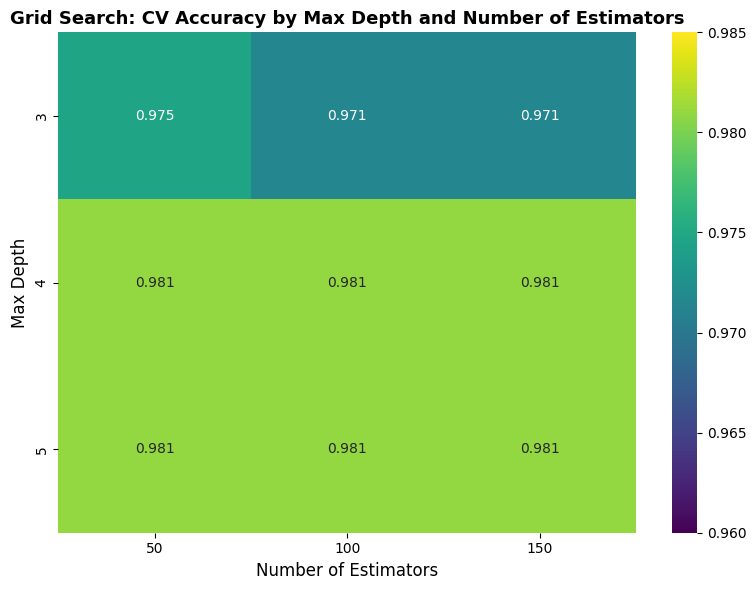

In [14]:
# Create pivot table of results (averaged over learning_rate)
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

print("Mean CV Accuracy by max_depth and n_estimators (averaged over learning_rate):")
print(pivot_table.round(4).to_string())

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.3f',
    cmap='viridis',
    vmin=0.96,
    vmax=0.985
)
plt.title('Grid Search: CV Accuracy by Max Depth and Number of Estimators',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Estimators', fontsize=12)
plt.ylabel('Max Depth', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

The heatmap reveals several important patterns about how hyperparameters interact:

**Max depth matters more than n_estimators.** The jump from `max_depth=3` to `max_depth=4` improves CV accuracy from approximately 97.1-97.5% to **98.1%** across all values of `n_estimators`. Going from `max_depth=4` to `max_depth=5` produces no further improvement. This suggests that the data requires exactly 4 levels of decision depth to capture the versicolor-virginica boundary, and anything beyond that adds no new information.

**N_estimators shows diminishing returns.** At `max_depth=3`, increasing from 50 to 100 or 150 trees actually *decreases* accuracy slightly (from 0.9746 to 0.9714). At `max_depth=4` and `max_depth=5`, the number of trees makes no difference whatsoever -- all values yield 0.9810. This confirms that on this small dataset, 50 trees are sufficient to capture the patterns, and additional trees contribute nothing.

**The plateau at 98.1%** across 6 of the 9 grid cells ($\text{max\_depth} \geq 4$ and any `n_estimators`) tells us that we have reached the performance ceiling for GBM on this data split. The remaining 1.9% of errors in cross-validation correspond to approximately $105 \times 0.019 \approx 2$ samples that are genuinely ambiguous.

**Production insight:** When the heatmap shows large plateau regions (as here), it means the model is robust to hyperparameter choices within that range. This is good news for production: we can safely pick any configuration in the plateau and expect consistent performance. When heatmaps show sharp gradients or narrow optimal regions, models are more fragile and require careful tuning.

## 8.5 Comparing Ensemble Methods

We now compare three fundamentally different ensemble strategies on the same data:

1. **Bagging (Random Forest):** Parallel independent trees, reduces variance
2. **Boosting (Gradient Boosting):** Sequential error-correcting trees, reduces bias
3. **Stacking:** Multiple diverse models whose predictions are combined by a meta-learner

**Stacking** is the most flexible ensemble technique. It trains multiple base models (here, a random forest and a GBM), then trains a **meta-model** (here, logistic regression) on the base models' predictions. The meta-model learns *when to trust each base model*:

$$\hat{y}_{\text{stack}} = g\left(\hat{y}_{\text{RF}}, \hat{y}_{\text{GBM}}\right)$$

where $g$ is the meta-learner. If one base model excels on certain types of inputs and another excels on different types, stacking can learn to combine them optimally.

### Building and Comparing All Three Ensembles

In [ ]:
# Instantiate all three ensemble models
rf_clf = RandomForestClassifier(n_estimators=100, random_state=2024)
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=2024)
stacking_clf = StackingClassifier(
    estimators=[('rf', rf_clf), ('gb', gb_clf)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

# Fit all models
rf_clf.fit(X_train, y_train)
gb_clf.fit(X_train, y_train)
stacking_clf.fit(X_train, y_train)

# Generate predictions
rf_pred = rf_clf.predict(X_test)
gb_pred = gb_clf.predict(X_test)
stacking_pred = stacking_clf.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)
stacking_accuracy = accuracy_score(y_test, stacking_pred)

print(f"Random Forest Accuracy:     {rf_accuracy:.2f}")
print(f"Gradient Boosting Accuracy: {gb_accuracy:.2f}")
print(f"Stacking Accuracy:          {stacking_accuracy:.2f}")

The ensemble comparison produces a clear ranking:

| Method | Accuracy | Correct / Total |
|:---|:---:|:---:|
| **Random Forest** (Bagging) | **0.91** | 41 / 45 |
| Gradient Boosting | 0.87 | 39 / 45 |
| Stacking (RF + GBM) | 0.87 | 39 / 45 |

**Random forest wins** on this dataset. This outcome makes sense when we consider the problem characteristics:

**Why bagging outperforms boosting here.** The Iris dataset is small ($n = 105$) and relatively clean (low noise, clear class structure). The primary source of error is **variance** -- sensitivity to which specific samples appear in the training set. Bagging directly targets variance, making it the ideal strategy. Boosting targets bias, which is not the bottleneck here; the single decision tree already has low bias (it can perfectly fit the training data), so boosting's sequential error correction adds little value while introducing overfitting risk.

**Why stacking does not improve over GBM.** Stacking combines RF and GBM predictions using logistic regression as a meta-learner. However, stacking can only be as good as the *best* base model if the base models make correlated errors. Since both RF and GBM struggle with the same versicolor-virginica boundary samples, their errors overlap significantly, giving the meta-learner little complementary information to exploit. Stacking shines when base models have *diverse* error patterns -- for instance, combining a tree-based model with a kernel SVM or neural network.

**Production insight:** On small, clean tabular datasets, random forests are often the best starting point. They require minimal hyperparameter tuning (more trees is almost always better), are robust to overfitting, and provide feature importance for free. Reserve gradient boosting for larger datasets where its ability to learn complex patterns justifies the additional tuning effort. Consider stacking only when you have genuinely diverse base models -- not just two variants of the same tree-based approach.

In [ ]:
# Create comparison bar chart
methods = ['Random Forest', 'Gradient Boosting', 'Stacking']
accuracies = [rf_accuracy, gb_accuracy, stacking_accuracy]
colors = ['#2196F3', '#FF7043', '#66BB6A']

plt.figure(figsize=(8, 6))
bars = plt.bar(methods, accuracies, color=colors, edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.005,
        f'{acc:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold'
    )

plt.title('Accuracy Comparison of Ensemble Methods',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.7, 1.0)
plt.axhline(y=accuracy, color='gray', linestyle='--', alpha=0.5,
            label=f'Single Decision Tree ({accuracy:.2f})')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart provides a clear visual comparison of the three ensemble methods against the single decision tree baseline (dashed gray line at 0.87). Random forest is the only ensemble that meaningfully surpasses the baseline, while gradient boosting and stacking match the decision tree exactly.

The dashed baseline reminds us of an important principle: **ensemble methods are not guaranteed to improve over single models**, especially on small datasets. The added complexity of boosting and stacking must be justified by measurable performance gains. Here, a random forest with its natural variance-reduction mechanism delivers the best return on model complexity.

## Chapter Summary

This chapter explored tree-based algorithms from a single decision tree to three ensemble paradigms. Here are the key takeaways:

### Algorithm Comparison

| Algorithm | Accuracy | Strategy | Best For |
|:---|:---:|:---|:---|
| Decision Tree | 86.67% | Single recursive partitioning | Interpretability, quick baseline |
| Random Forest | **91.11%** | Parallel bagging with feature randomization | Variance-dominated problems, robust default |
| GBM (untuned) | 86.67% | Sequential boosting | Large datasets with complex patterns |
| GBM (tuned) | 86.67% | Tuned sequential boosting | When careful tuning is feasible |
| Stacking | 86.67% | Meta-learning over diverse base models | Diverse model combinations |

### Key Principles

**The bias-variance tradeoff is central to tree-based methods.** Decision trees have low bias but high variance; random forests reduce variance through averaging; GBMs reduce bias through sequential correction. Understanding which source of error dominates your problem determines which ensemble strategy to use.

**Hyperparameter tuning is essential for boosting.** We demonstrated that a GBM with default parameters ($B = 1{,}000$, $\eta = 0.2$) matched a single decision tree, while the optimal configuration ($B = 50$, $\eta = 0.01$) achieved 98.1% in cross-validation. The effective complexity $B \times \eta$ dropped from 200 to 0.5 -- a 400-fold reduction.

**More complex does not always mean better.** On our small 150-sample Iris dataset, the simplest ensemble (random forest) outperformed both boosting and stacking. Reserve advanced techniques for problems where the data can support their additional complexity.

**Feature importance guides feature engineering.** Petal features accounted for 88.5% of the random forest's decision-making power, confirming domain knowledge and guiding potential dimensionality reduction.

In the chapters ahead, we will encounter more powerful boosting implementations (XGBoost, LightGBM) and tackle larger datasets where the full power of gradient boosting truly shines.